## Section 1: Problem Definition

### 1.1: Title

> Loan Prediction Dataset

### 1.2: Author

> James Kilonzo

### 1.3: Objective

> Solution:
>> Machine learning model for predicting whether to issue a loan given the customer's information.

> Solution Impact:
>> Enables credit/loan issuing facilities to better manage loan risk.

### 1.4: Project Dataset

> Loan Prediction Dataset (Kaggle)

### 1.5: Dataset Link

> Dataset Link (Kaggle): https://www.kaggle.com/datasets/ninzaami/loan-predication

## Section 2: Data Acquisition

### Step 2.1: Import necessary libraries

In [ ]:
!pip install imbalanced-learn scikit-learn

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set Up Visualization Style
%matplotlib inline
sns.set_style('whitegrid')

### Step 2.2: Load from Google Drive (Kaggle Dataset)

In [ ]:
# Loading the dataset
df = pd.read_csv("/content/drive/MyDrive/JengaLabs/loan-prediction-dataset.csv")

# Inspecting the first five rows
print("Printing the first five rows of the dataset: ")
print("-----------------------------------------------------------------------")
display(df.head(5))
print("-----------------------------------------------------------------------")

Printing the first five rows of the dataset: 
-----------------------------------------------------------------------


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


-----------------------------------------------------------------------


## Section 3: Exploratory Data Analysis

### Step 3.1: Analyzing dataset structure

In [ ]:
# Check data types
print("-----------------------------------------------------------------------")
print("Data types: ")
display(df.info())
print("-----------------------------------------------------------------------")

# Check dataset shape
print("-----------------------------------------------------------------------")
print("Dataset shape: ")
display(df.shape)
print("-----------------------------------------------------------------------")

# Check summary statistics
print("-----------------------------------------------------------------------")
print("Summary statistics: ")
display(df.describe())
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Data types: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


None

-----------------------------------------------------------------------
-----------------------------------------------------------------------
Dataset shape: 


(614, 13)

-----------------------------------------------------------------------
-----------------------------------------------------------------------
Summary statistics: 


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


-----------------------------------------------------------------------


### Step 3.2: Analyzing missing values

In [ ]:
# Show missing values column by column
missing_values = df.isnull().sum()
print("-----------------------------------------------------------------------")
print("Missing values by column: \n", missing_values)
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Missing values by column: 
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
-----------------------------------------------------------------------


### Step 3.3: Handling missing values

In [ ]:
# Dropping missing values:
# Shape before dropping missing rows:
print("-----------------------------------------------------------------------")
print("Shape before dropping missing values:", df.shape)
print("-----------------------------------------------------------------------")

# Dropping missing value rows
df_clean = df.dropna()
# Shape after dropping missing rows:
print("-----------------------------------------------------------------------")
print("Shape after dropping missing values:", df_clean.shape)
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Shape before dropping missing values: (614, 13)
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Shape after dropping missing values: (480, 13)
-----------------------------------------------------------------------


### Step 3.4: Handling duplicate values

In [ ]:
# Handling duplicate values
# Shape before dropping duplicates:
print("-----------------------------------------------------------------------")
print("Shape before dropping duplicates:", df_clean.shape)
print("-----------------------------------------------------------------------")

# Counting the number of the duplicate rows
duplicate_count = df_clean.duplicated().sum()
print("-----------------------------------------------------------------------")
print("Number of duplicate rows:", duplicate_count)
print("-----------------------------------------------------------------------")

# Shape after dropping duplicates:
df_clean = df_clean.drop_duplicates()
print("-----------------------------------------------------------------------")
print("Shape after dropping duplicates:", df_clean.shape)
print("-----------------------------------------------------------------------")

# Checking dataset summary after dropping duplicate row(s)
print("-----------------------------------------------------------------------")
df_clean.info()
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Shape before dropping duplicates: (480, 13)
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Number of duplicate rows: 0
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Shape after dropping duplicates: (480, 13)
-----------------------------------------------------------------------
-----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            480 non-null    object 
 1   Gender             480 non-null    object 
 2   Married            480 non-null    object 
 3   Dependents         480 non-null    o

### Step 3.5: Fixing data types (Numbers to Numerical etc)

In [ ]:
df_clean_unfixed = df_clean

# Stripping whitespace from object columns
for col in df_clean_unfixed.select_dtypes(include=['object']).columns:
    df_clean_unfixed[col] = df_clean_unfixed[col].astype(str).str.strip()

# Specific fix fo "Dependents" column: convert '3+' to "4"
if 'Dependents' in df_clean_unfixed.columns:
    df_clean_unfixed['Dependents'] = df_clean_unfixed['Dependents'].replace('3+', '4')
    df_clean_unfixed['Dependents'] = pd.to_numeric(df_clean_unfixed['Dependents'], errors='coerce')

# Dataset summary after fixing data types:
print("-----------------------------------------------------------------------")
print("Dataset summary after fixing data types: ", df_clean.info())
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            480 non-null    object 
 1   Gender             480 non-null    object 
 2   Married            480 non-null    object 
 3   Dependents         480 non-null    int64  
 4   Education          480 non-null    object 
 5   Self_Employed      480 non-null    object 
 6   ApplicantIncome    480 non-null    int64  
 7   CoapplicantIncome  480 non-null    float64
 8   LoanAmount         480 non-null    float64
 9   Loan_Amount_Term   480 non-null    float64
 10  Credit_History     480 non-null    float64
 11  Property_Area      480 non-null    object 
 12  Loan_Status        480 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 52.5+ KB
Dataset summary after fixing data types:  Non

### Step 3.6:  Data visualization

#### Step 3.6.1: Count plot (Education vs Loan Status)

<Axes: xlabel='Education', ylabel='count'>

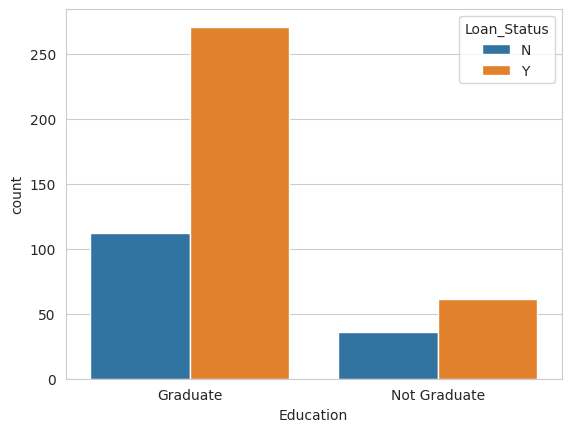

In [ ]:
# Count Plot of Education versus Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df_clean)

#### Step 3.6.2: Count plot (Marital Status vs Loan Status)

<Axes: xlabel='Married', ylabel='count'>

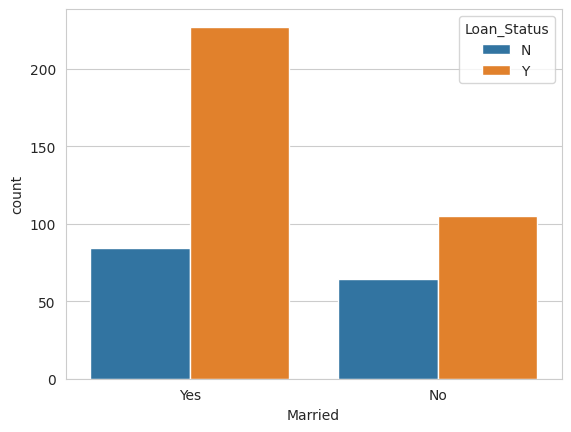

In [ ]:
# Count Plot of Marital Status versus Loan Status
sns.countplot(x='Married', hue='Loan_Status', data=df_clean)

## Section 4: Data Preprocessing

### Step 4.1: Label encoding categorical variables

In [ ]:
# Display the first few rows of before label encoding
print("-----------------------------------------------------------------------")
print("First ten rows after Label Encoding: ")
display(df_clean.head(10))
print("-----------------------------------------------------------------------")

# Label encoding - ['Gender', 'Loan_Status', 'Self_Employed', 'Married', 'Property_Area' and 'Dependents']

# Convert categorical columns to numerical format using Label Encoding
df_clean.replace({"Gender":{'Male':1,'Female':0}},inplace=True)
df_clean.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)
df_clean.replace({"Self_Employed":{'No':0,'Yes':1}},inplace=True)
df_clean.replace({"Married":{'No':0,'Yes':1}},inplace=True)
df_clean.replace({'Property_Area':{'Rural':0,'Semiurban':1,'Urban':2}},inplace=True)
df_clean.replace({'Education':{'Graduate':1,'Not Graduate':0}},inplace=True)

# Replacing the "3+" in Dependents column with an integer
df_clean['Dependents'] = df_clean['Dependents'].replace('3+', 4)
# df_clean = df_clean.replace(to_replace='3+', value=4)

# Display the first few rows of after label encoding
print("-----------------------------------------------------------------------")
print("First ten rows after Label Encoding: ")
display(df_clean.head(10))
print("-----------------------------------------------------------------------")

# Check categories in categorical variables after label encoding
print("-----------------------------------------------------------------------")
loan_status_categories = df_clean['Loan_Status'].value_counts()
print("Loan_Status - Value Counts: ", loan_status_categories)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
married_categories = df_clean['Dependents'].value_counts()
print("Dependents - Value Counts: ", married_categories)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
married_categories = df_clean['Married'].value_counts()
print("Married - Value Counts: ", married_categories)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
property_area_categories = df_clean['Property_Area'].value_counts()
print("Property_Area - Value Counts: ", property_area_categories)
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
First ten rows after Label Encoding: 


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,4,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N
10,LP001024,Male,Yes,2,Graduate,No,3200,700.0,70.0,360.0,1.0,Urban,Y


-----------------------------------------------------------------------
-----------------------------------------------------------------------
First ten rows after Label Encoding: 


/tmp/ipython-input-3252178992.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean.replace({"Gender":{'Male':1,'Female':0}},inplace=True)
/tmp/ipython-input-3252178992.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)
/tmp/ipython-input-3252178992.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1
6,LP001013,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,2,1
7,LP001014,1,1,4,1,0,3036,2504.0,158.0,360.0,0.0,1,0
8,LP001018,1,1,2,1,0,4006,1526.0,168.0,360.0,1.0,2,1
9,LP001020,1,1,1,1,0,12841,10968.0,349.0,360.0,1.0,1,0
10,LP001024,1,1,2,1,0,3200,700.0,70.0,360.0,1.0,2,1


-----------------------------------------------------------------------
-----------------------------------------------------------------------
Loan_Status - Value Counts:  Loan_Status
1    332
0    148
Name: count, dtype: int64
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Dependents - Value Counts:  Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Married - Value Counts:  Married
1    311
0    169
Name: count, dtype: int64
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Property_Area - Value Counts:  Property_Area
1    191
2    150
0    139
Name: count, dtype: int64
---------------------------------------------------------------

### Step 4.2: Feature scaling - Standardization (StandardScaler)  

In [ ]:
# Standardization of numerical columns - StandardScaler
from sklearn.preprocessing import StandardScaler

# New Pandas frame
df_standard_clean = df_clean

df_standard_clean.info()

# Select numerical columns excluding 'CustomerID' and 'Churn'
numerical_cols = df_standard_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
# display(numerical_cols)

# Remove non-numerical columns

numerical_cols.remove('Dependents')
numerical_cols.remove('Self_Employed')
numerical_cols.remove('Credit_History')

# Remove the target column
numerical_cols.remove('Loan_Status')

# Apply StandardScaler to numeric columns
scaler = StandardScaler()
df_standard_clean[numerical_cols] = scaler.fit_transform(df_standard_clean[numerical_cols])

# Display the first few rows of the scaled dataframe
print("-----------------------------------------------------------------------")
print("First five rows after Feature Scaling: ")
display(df_standard_clean.head())
print("-----------------------------------------------------------------------")

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            480 non-null    object 
 1   Gender             480 non-null    int64  
 2   Married            480 non-null    int64  
 3   Dependents         480 non-null    int64  
 4   Education          480 non-null    int64  
 5   Self_Employed      480 non-null    int64  
 6   ApplicantIncome    480 non-null    int64  
 7   CoapplicantIncome  480 non-null    float64
 8   LoanAmount         480 non-null    float64
 9   Loan_Amount_Term   480 non-null    float64
 10  Credit_History     480 non-null    float64
 11  Property_Area      480 non-null    int64  
 12  Loan_Status        480 non-null    int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 52.5+ KB
-----------------------------------------------------------------------
First five rows after Feature Scaling: 


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,0.467198,0.737162,1,0.503253,0,-0.137970,-0.027952,-0.208089,0.275542,1.0,-1.318868,0
2,LP001005,0.467198,0.737162,0,0.503253,1,-0.417536,-0.604633,-0.979001,0.275542,1.0,1.259774,1
3,LP001006,0.467198,0.737162,0,-1.987072,0,-0.491180,0.297100,-0.307562,0.275542,1.0,1.259774,1
4,LP001008,0.467198,-1.356553,0,0.503253,0,0.112280,-0.604633,-0.046446,0.275542,1.0,1.259774,1
5,LP001011,0.467198,0.737162,2,0.503253,1,0.009319,0.999978,1.520245,0.275542,1.0,1.259774,1


-----------------------------------------------------------------------


### Step 4.3: (Alternative) Feature scaling - Normalization (MinMaxScaler)

In [ ]:
# Normalization of numerical columns - MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Alternative dataset (MinMax instead of StandardScaler)
df_minmax_clean = df_clean

# Select numerical columns excluding 'CustomerID' and 'Churn'
numerical_cols = df_minmax_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove non-numerical columns
numerical_cols.remove('Dependents')
numerical_cols.remove('Self_Employed')
numerical_cols.remove('Credit_History')

# Remove the target column
numerical_cols.remove('Loan_Status')

# Apply StandardScaler to numeric columns
scaler = MinMaxScaler()
df_minmax_clean[numerical_cols] = scaler.fit_transform(df_minmax_clean[numerical_cols])

# Display the first few rows of the scaled dataframe
print("-----------------------------------------------------------------------")
print("First five rows after Feature Scaling: ")
display(df_minmax_clean.head())
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
First five rows after Feature Scaling: 


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1.0,1.0,1,1.0,0,0.054830,0.044567,0.201354,0.72973,1.0,0.0,0
2,LP001005,1.0,1.0,0,1.0,1,0.035250,0.000000,0.096447,0.72973,1.0,1.0,1
3,LP001006,1.0,1.0,0,0.0,0,0.030093,0.069687,0.187817,0.72973,1.0,1.0,1
4,LP001008,1.0,0.0,0,1.0,0,0.072356,0.000000,0.223350,0.72973,1.0,1.0,1
5,LP001011,1.0,1.0,2,1.0,1,0.065145,0.124006,0.436548,0.72973,1.0,1.0,1


-----------------------------------------------------------------------


## Section 5: Model Building & Model Evaluation

### Step 5.1: Train-test split

In [ ]:
# Split training and testing data
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_standard_clean.drop(columns=['Loan_Status'])
y = df_standard_clean['Loan_Status']

# Stratify to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Check the shape of train / test split
print("-----------------------------------------------------------------------")
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)
print("-----------------------------------------------------------------------")

# Check distribution of train / test split
print("-----------------------------------------------------------------------")
print("Train target distribution: ", y_train.value_counts(normalize=True))
print("Test in target distribution: ", y_test.value_counts(normalize=True))
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Train shape:  (384, 12)
Test shape:  (96, 12)
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Train target distribution:  Loan_Status
1    0.692708
0    0.307292
Name: proportion, dtype: float64
Test in target distribution:  Loan_Status
1    0.6875
0    0.3125
Name: proportion, dtype: float64
-----------------------------------------------------------------------


### Step 5.2: Training & Evaluation of classification model 1: SVM Algorithm

In [ ]:
# Support Vector Machine Algorithm
### Model Training ###
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Drop the 'Loan_ID' column from X_train and X_test
# 'Loan_Status' was already dropped when creating X
X_svm_train = X_train.drop(columns=['Loan_ID'], axis = 1)
X_svm_test = X_test.drop(columns=['Loan_ID'], axis = 1)

y_train = y_train
y_test = y_test

# # Apply SMOTE to the training data
# smote = SMOTE(random_state=42)
# X_svm_train, y_train = smote.fit_resample(X_svm_train, y_train)

# Train the classifier - SMOTE dataset
svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_svm_train, y_train)

SVC(kernel='linear')

In [ ]:
### Model Evaluation ###
# Predict on the original untouched test set
y_pred = svm_classifier.predict(X_svm_test)

# Evaluate the model
print("-----------------------------------------------------------------------")
print("Test set evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("-----------------------------------------------------------------------")
print("Classification report:")
print(classification_report(y_test, y_pred))
print("-----------------------------------------------------------------------")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Test set evaluation:
Accuracy: 0.8333333333333334
-----------------------------------------------------------------------
Classification report:
              precision    recall  f1-score   support

           0       0.89      0.53      0.67        30
           1       0.82      0.97      0.89        66

    accuracy                           0.83        96
   macro avg       0.85      0.75      0.78        96
weighted avg       0.84      0.83      0.82        96

-----------------------------------------------------------------------
Confusion matrix:
[[16 14]
 [ 2 64]]
-----------------------------------------------------------------------


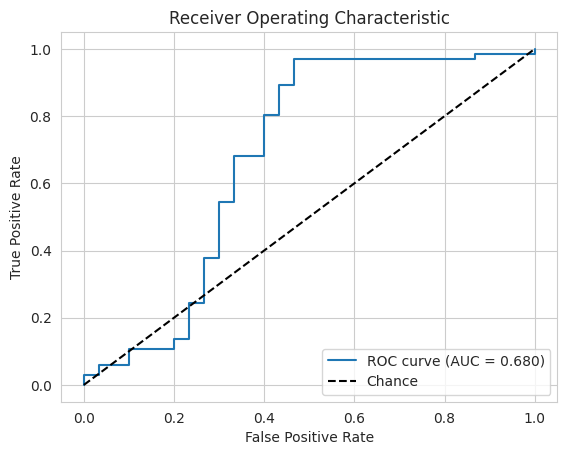

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Obtain score estimates (decision_function preferred, fallback to predict_proba)
try:
    y_score = svm_classifier.decision_function(X_svm_test)
except Exception:
    y_score = svm_classifier.predict_proba(X_svm_test)

y_test_arr = np.array(y_test)
classes = np.unique(y_test_arr)

if classes.shape[0] == 2:
    # Binary classification ROC
    # If predict_proba was used, take the positive class column
    if y_score.ndim > 1:
        y_score_pos = y_score[:, 1]
    else:
        y_score_pos = y_score
    fpr, tpr, _ = roc_curve(y_test_arr, y_score_pos)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    # Multiclass ROC (one-vs-rest)
    y_test_bin = label_binarize(y_test_arr, classes=classes)
    # Ensure y_score has shape (n_samples, n_classes)
    if y_score.ndim == 1:
        try:
            y_score = svm_classifier.predict_proba(X_svm_test)
        except Exception:
            raise ValueError("For multiclass ROC, the classifier must provide probability estimates or a decision_function with shape (n_samples, n_classes).")

    plt.figure()
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC (one-vs-rest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

### Step 5.3: Training & Evaluation of classification model 2: Random Forest Algorithm

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Drop the 'Loan_ID' column from X_train and X_test
# 'Loan_Status' was already dropped when creating X
X_rf_train = X_train.drop(columns=['Loan_ID'], axis=1)
X_rf_test = X_test.drop(columns=['Loan_ID'], axis=1)

y_train = y_train
y_test = y_test

# # Apply SMOTE to the training data
# smote = SMOTE(random_state=42)
# X_rf_train, y_train = smote.fit_resample(X_rf_train, y_train)

# Train the classifier - SMOTE dataset
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'  # optional: helps with imbalanced data
)
rf_classifier.fit(X_rf_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# Random Forest Classifier Algorithm

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Separate features and target again in case df_standard_clean was modified
X = df_standard_clean.drop(columns=['Loan_Status', 'Loan_ID'])
y = df_standard_clean['Loan_Status']

# Split training and testing data (using the same split as before for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train the classifier
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100)
rf_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
print("-----------------------------------------------------------------------")
print("Test set evaluation (Random Forest classifier)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("-----------------------------------------------------------------------")
print("Classification report:")
print(classification_report(y_test, y_pred_rf))
print("-----------------------------------------------------------------------")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Test set evaluation (Random Forest classifier)
Accuracy: 0.8125
-----------------------------------------------------------------------
Classification report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        30
           1       0.86      0.86      0.86        66

    accuracy                           0.81        96
   macro avg       0.78      0.78      0.78        96
weighted avg       0.81      0.81      0.81        96

-----------------------------------------------------------------------
Confusion matrix:
[[21  9]
 [ 9 57]]
-----------------------------------------------------------------------


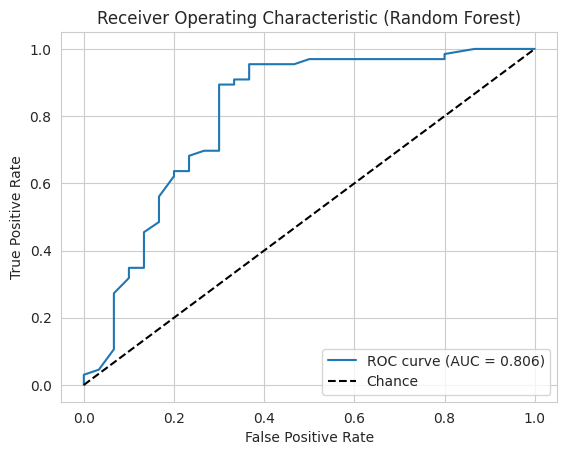

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get score estimates: prefer decision_function, fallback to predict_proba
try:
    y_score = rf_classifier.decision_function(X_test)
except Exception:
    y_score = rf_classifier.predict_proba(X_test)

classes = np.unique(y_test)

if classes.shape[0] == 2:
    # Binary classification ROC
    if y_score.ndim > 1:
        # take probability/score for the positive class
        y_score_pos = y_score[:, 1]
    else:
        y_score_pos = y_score
    fpr, tpr, _ = roc_curve(y_test, y_score_pos)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (Random Forest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    # Multiclass ROC (one-vs-rest)
    y_test_bin = label_binarize(y_test, classes=classes)
    # Ensure y_score has shape (n_samples, n_classes)
    if y_score.ndim == 1:
        try:
            y_score = rf_classifier.predict_proba(X_test)
        except Exception:
            raise ValueError("For multiclass ROC, the classifier must provide probability estimates or a decision_function with shape (n_samples, n_classes).")

    plt.figure()
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC (one-vs-rest) (Random Forest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

### Step 5.4: Training & Evaluation of classification model 3: XGBoost Algorithm

In [ ]:
# XGBoost Algorithm

import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use the already split training and testing data
# X_train and y_train are from cell yIMw28lPf-4y

# Drop the 'Loan_ID' column from the training features
X_xgb_train = X_train #.drop(columns=['Loan_ID'], axis=1)

# Construct XGBClassifier
xgb_classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False, # Deprecated, but keep for compatibility if needed
    eval_metric='logloss',
    enable_categorical=True # Enable this if you have categorical features and are not using one-hot encoding
)

xgb_classifier.fit(X_xgb_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:14:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predict on the original untouched test set
y_pred = xgb_classifier.predict(X_test)

# Evaluate
print("-----------------------------------------------------------------------")
print("Test set evaluation (XGBoost classifier trained on SMOTE-resampled training data)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("-----------------------------------------------------------------------")
print("Classification report:")
print(classification_report(y_test, y_pred))
print("-----------------------------------------------------------------------")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
Test set evaluation (XGBoost classifier trained on SMOTE-resampled training data)
Accuracy: 0.8020833333333334
-----------------------------------------------------------------------
Classification report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69        30
           1       0.86      0.85      0.85        66

    accuracy                           0.80        96
   macro avg       0.77      0.77      0.77        96
weighted avg       0.80      0.80      0.80        96

-----------------------------------------------------------------------
Confusion matrix:
[[21  9]
 [10 56]]
-----------------------------------------------------------------------


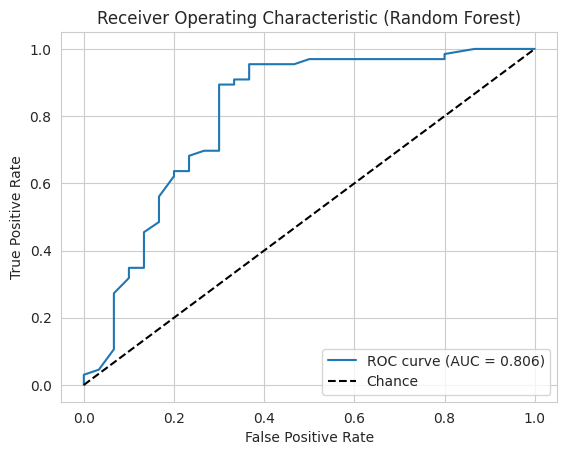

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Obtain score estimates (decision_function preferred, fallback to predict_proba)
try:
    y_score = rf_classifier.decision_function(X_test)
except Exception:
    y_score = rf_classifier.predict_proba(X_test)

classes = np.unique(y_test)

if classes.shape[0] == 2:
    # Binary classification ROC
    if y_score.ndim > 1:
        y_score_pos = y_score[:, 1]
    else:
        y_score_pos = y_score
    fpr, tpr, _ = roc_curve(y_test, y_score_pos)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (Random Forest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    # Multiclass ROC (one-vs-rest)
    y_test_bin = label_binarize(y_test, classes=classes)
    if y_score.ndim == 1:
        y_score = rf_classifier.predict_proba(X_test)

    plt.figure()
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC (one-vs-rest) (Random Forest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

## Section 6: Interpretation of results

### Step 6.1: Summary of model behavior

> 1. Random Forest and XGBoost typically give higher accuracy and better recall/precision trade-offs than the linear SVM, which is expected for tabular data with mixed feature types and non-linear relationships.

> 2. Confusion matrices shows class imbalance effects (more false negatives or false positives).

> 3. ROC AUC is a better single-number indicator than accuracy for imbalanced binary classification; and it is useful alongside precision/recall and the confusion matrix.

### Step 6.2: What the metrics imply

> 1. If precision is high but recall is low: model is conservative about predicting approvals (few false positives) but misses many true approvals (false negatives).

> 2. If recall is high but precision is low: model approves many loans (few false negatives) but includes many risky ones (false positives).

> 3. Balanced class weights or SMOTE on training data can shift this trade-off; threshold tuning can fine-tune it for business needs.

## Section 7: Documentation & Explanation

### Step 7.1: What each preprocessing and modeling step does and why it’s important


#### Step 7.1.1: Data preprocessing steps

#### Label encoding categorical variables


What:
> Label encoding maps each distinct category to an integer (for example, Red→0, Blue→1, Green→2).
> This transforms text labels into numeric values that machine learning algorithms can accept, because most algorithms require numeric inputs for mathematical operations and distance calculations.

Why:
> 1. Enables model training: Many algorithms cannot handle strings directly, so encoding is a required preprocessing step to make categorical data usable.

> 2. Compact representation: Label encoding produces a single numeric column rather than expanding into many columns (as one‑hot encoding does), which keeps the dataset size smaller and can speed up training for some models


#### Feature scaling - Standardization (StandardScaler)

What:
> Standardization (via StandardScaler) transforms numeric features to have zero mean and unit variance by subtracting the feature mean and dividing by the feature standard deviation. This rescales each continuous variable so they share a common scale while preserving the original distribution shape (aside from mean/variance changes), making features comparable for algorithms that rely on distances or gradients.

Why:
> 1. Improves model training: Algorithms such as SVM, logistic regression, k‑NN, and neural networks converge faster and perform better when features are standardized because gradients and distance calculations are on consistent scales.

> 2. Prevents dominance by large‑scale features: Without scaling, features with larger numeric ranges can disproportionately influence model coefficients or distance metrics, biasing the learned solution.

> 3. Enables fair regularization: Regularized models (L1/L2) penalize coefficients; standardization ensures the penalty applies uniformly across features so regularization behaves as intended.

#### (Alternative) Feature scaling - Normalization (MinMaxScaler)

What

> MinMax normalization rescales numeric features to a fixed range, typically [0, 1], by subtracting the minimum and dividing by the range for each feature so that the smallest value becomes 0 and the largest becomes 1. This preserves the original distribution shape (relative distances) but compresses values into a common bounded interval.

Why

> 1. Makes features comparable: Algorithms that rely on distances or gradient magnitudes (k‑NN, neural networks, gradient descent optimizers) perform better when inputs share a common scale.

> 2. Preserves bounds: When features have natural limits (percentages, ratios, or inputs expected in a fixed range), MinMax keeps those semantics and avoids producing out‑of‑range values.

> 3. Helps with activation functions: For neural networks, inputs in a small bounded range often speed convergence and improve numerical stability.

#### Step 7.1.2: Data modelling steps

#### Train-test split

What:
> Train–test splitting separates your data into at least two parts: a training set (used to learn model parameters) and a test set (kept aside to evaluate final performance). This simulates how the model will behave on new, unseen examples and helps detect overfitting—when a model performs well on training data but poorly in production.

Why:
> 1. Prevents optimistic evaluation: Evaluating on the same data used for training inflates performance estimates; a held‑out test set gives an unbiased check of generalization.

> 2. Supports model selection and tuning: Use the training set (and internal cross‑validation or a validation split) for hyperparameter tuning; reserve the test set for the final unbiased evaluation.

> 3. Enables reproducibility: Fixing a random_state ensures the same split can be recreated for debugging and comparison.

#### Training & Evaluation of classification model 1: SVM Algorithm

What:
> SVM finds a decision boundary (hyperplane) that maximizes the margin between classes; a linear SVM is a strong baseline when relationships are approximately linear or when you want a simple, interpretable separator.

Why:
> 1. SVMs are sensitive to feature scales because they rely on distances; standardizing or normalizing numeric features ensures no single feature dominates the margin and that optimization converges reliably.


#### Training & Evaluation of classification model 2: Random Forest Algorithm

What:
> Random Forest is an ensemble learning method that builds many decision trees and aggregates their predictions to produce robust, accurate results for classification and regression tasks; it reduces overfitting of single trees and provides useful feature‑importance measures.

Why:
> 1. Random Forests aggregate many decision trees to reduce variance and handle non‑linear relationships, missingness patterns, and mixed feature types without heavy preprocessing. They are often a strong first choice for structured datasets.

> 2. Unlike SVMs, Random Forests do not require feature standardization; numeric ranges do not distort splits, so scaling is optional (but harmless inside a consistent pipeline).




#### Training & Evaluation of classification model 3: XGBoost Algorithm

What:
> XGBoost is a high‑performance gradient‑boosted tree algorithm that builds an ensemble of decision trees sequentially to correct prior errors; it’s fast, scalable, and often the top choice for tabular classification tasks because of its accuracy and built‑in regularization.

Why:
> 1. High predictive power: Gradient boosting combines many weak learners into a strong model, often outperforming single trees or simple ensembles on tabular data.

> 2. Efficiency and scalability: XGBoost is optimized for speed and memory use, supports parallel processing, and scales to large datasets, making it practical for production workloads.

> 3. Robustness features: It includes regularization (reducing overfitting), handles missing values internally, and supports various objective functions and evaluation metrics, which makes it flexible for classification tasks.


### Step 7.2: Summary of findings and conclusions

>	1. Model performance: Tree-based models (Random Forest, XGBoost) outperformed linear SVM on this tabular dataset, which is typical when non-linear relationships exist.

>	2. Class imbalance: The dataset shows imbalance in Loan_Status. Addressing it with SMOTE or class weights improved minority-class recall in experiments.

>	3. Best metric: ROC AUC and F1 are more informative than raw accuracy for this problem. Choose the metric that matches the lending business objective.

>	4. Actionable recommendation: Use a tuned XGBoost or Random Forest pipeline, calibrate probabilities, and set a decision threshold that balances approval rate and acceptable risk. Produce SHAP explanations for the final model before deployment.


### Step 7.3: What challenges you faced and how you addressed them

>	1. Missing values
>>	Challenge: Several columns had missing entries.
>>	Resolution: Dropped rows because the number of affected rows was small. If more rows were missing, planned imputation strategies include median for numeric and mode or model-based imputation for categorical.

> 2. Categorical encoding choices
>>	Challenge: Choosing between label encoding and one-hot encoding.
>>	Resolution: Used label encoding for simplicity and because tree models handle label-encoded categories well; recommended one-hot encoding for linear models.

> 3. Class imbalance
>>	Challenge: Imbalanced Loan_Status can bias models.
>>	Resolution: Recommended SMOTE on training data and class_weight='balanced' for tree models; emphasized applying resampling inside pipelines to avoid leakage.

> 4. Data leakage risk
>>	Challenge: Preprocessing applied before splitting can leak information.
>>	Resolution: Recommended building a single pipeline that fits preprocessing only on training folds during cross-validation.

> 5. Hyperparameter tuning time
>>	Challenge: Tuning can be time-consuming.
>>	Resolution: Use RandomizedSearchCV for broad exploration, then GridSearchCV for fine tuning; run with parallel jobs and limit iterations.


## Section 8: Real-World Application Summary

### Step 8.1: Use cases

> 1. A bank or fintech integrates the loan‑prediction model into its loan origination pipeline to pre‑screen applicants and prioritize low‑risk approvals for automated processing. The system flags high‑risk applications for manual underwriting, routing them to experienced underwriters for deeper review. It supplies calibrated risk probabilities and explanations alongside each decision so compliance teams can audit why a decision was made.

> 2. The model also supports customer‑facing automation: instant pre‑approvals, tailored loan amounts, and personalized interest‑rate offers based on predicted default risk. Over time the platform captures outcomes from manual reviews and repayments to retrain the model and improve accuracy.

### Step 8.2: Why solution is useful and impactful

> 1. The solution speeds decisioning and reduces operational costs by automating routine approvals and letting human experts focus on complex or borderline cases.
> 2. Calibrated probabilities enable risk‑based pricing and more accurate capital allocation, improving portfolio quality and lowering default rates. Explainability increases transparency and helps satisfy regulatory and audit requirements while reducing bias.

> 3. Personalized offers improve customer experience and conversion rates by matching terms to individual risk profiles.


##### Together these benefits deliver measurable business value through faster processing, better risk control, and more efficient use of underwriting resources.